**The dataset which is used in this project is a multi class weather dataset.The images in the dataset are classified into multiple categories, specifically: sunrise, rain, cloudy, and shine.There are a total of 1122 images.**

## **Loading the Data**

Loading the data from google drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Setting the folder path of the images

import os

folder_path = '/content/drive/MyDrive/dataset2'

I have created a function to load images from the drive. The images are resized to 128x128, converted to RGB, and normalized by dividing pixel values by 255.0 to scale them between 0 and 1.

In [ ]:
import numpy as np
from PIL import Image

def load_and_preprocess_images_from_drive(folder_path, target_size=(128, 128)):
    images = []
    labels = []

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if filename.endswith('.jpg'):  # Adjust if you have different extensions
            try:
                image = Image.open(file_path).convert('RGB')  # Convert to RGB
                image = image.resize(target_size)
                image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
                images.append(image)

                # Label extraction based on naming convention
                if "cloudy" in filename:
                    labels.append(0)
                elif "rain" in filename:
                    labels.append(1)
                elif "shine" in filename:
                    labels.append(2)
                elif "sunrise" in filename:
                    labels.append(3)
                else:
                    print(f"Unknown label for file: {filename}")

            except Exception as e:
                print(f"Error processing file {filename}: {e}")

    if not images:
        print("No images were loaded. Please check the image formats and directory structure.")

    images = np.array(images)
    labels = np.array(labels)

    return images, labels

# Example usage
images, labels = load_and_preprocess_images_from_drive(folder_path)
if len(images) > 0:
    print(f"Loaded {len(images)} images with shape {images[0].shape} each.")
else:
    print("No images loaded.")

Loaded 1122 images with shape (128, 128, 3) each.


#**Exploratory Analysis**

I have defined a function to display 5 images.

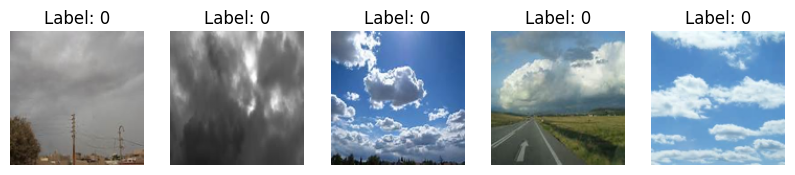

In [ ]:
import matplotlib.pyplot as plt

def preview_images(images, labels, num_images=5):
    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        ax = plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i])
        plt.title(f"Label: {labels[i]}")
        plt.axis("off")

# Preview a few loaded images
preview_images(images, labels)

### **Class Distribution Plot**

A function is created to visualize the class distribution of the dataset. It counts the number of images in each category and plots a bar chart. The chart uses the labels of the classes (Cloudy,Rain,Shine and sunrise). This helps us to understand if the data is balanced or imbalanced.

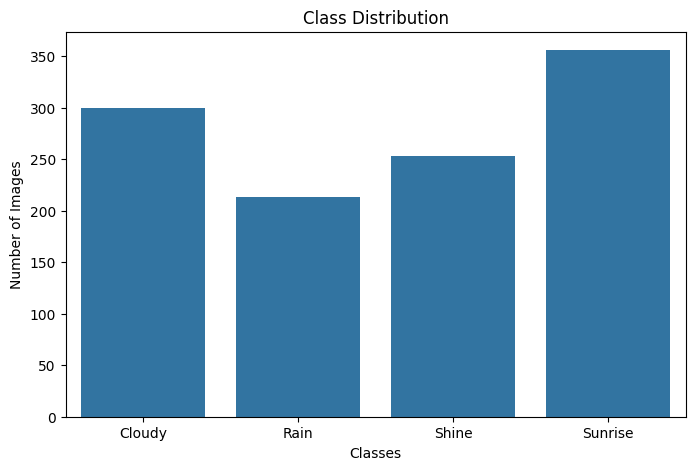

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_class_distribution(labels):
    class_names = ["Cloudy", "Rain", "Shine", "Sunrise"]
    unique, counts = np.unique(labels, return_counts=True)
    class_counts = dict(zip(unique, counts))

    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
    plt.xticks(ticks=range(len(class_names)), labels=class_names)
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")
    plt.title("Class Distribution")
    plt.show()

plot_class_distribution(labels)


 In the above plot we can see that sunrise has the highest number of images while the class rain has the least number of images. We can see that the dataset is imbalanced.

### **Pixel Intensity Distribution Plot**

A function is created to visualize the pixel intensity distribution of the dataset. It flattens all the pixel values from the images into a single array and plots a histogram. The histogram shows the frequency of pixel values, which are normalized between 0 and 1. This helps to understand the distribution of pixel intensities across the dataset.

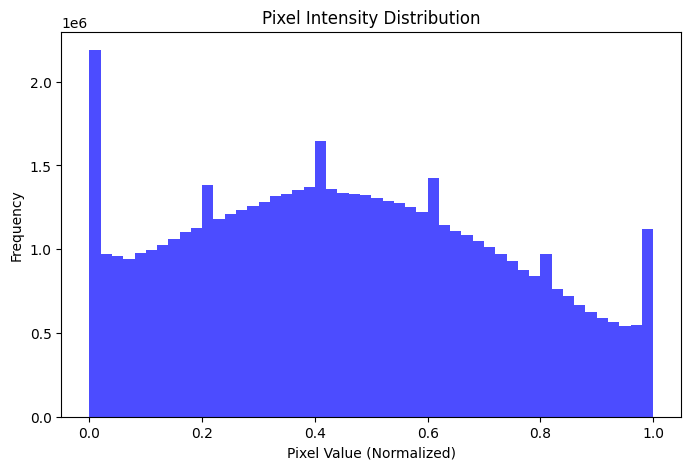

In [ ]:
def plot_pixel_intensity_distribution(images):
    flat_pixels = images.ravel()  # Flatten all pixel values
    plt.figure(figsize=(8, 5))
    plt.hist(flat_pixels, bins=50, color='blue', alpha=0.7)
    plt.xlabel("Pixel Value (Normalized)")
    plt.ylabel("Frequency")
    plt.title("Pixel Intensity Distribution")
    plt.show()

# Plot pixel intensity distributions
plot_pixel_intensity_distribution(images)

### **Image Dimensions (Before Resizing) Plot**

The function extracts the width and height of each image and plots them as a scatter plot. This helps to understand the variation in image sizes and identify any outliers in dimensions.

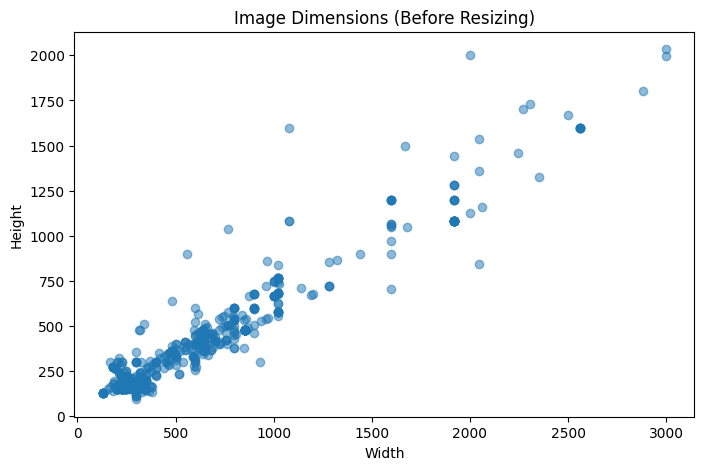

In [ ]:
def plot_image_dimensions(folder_path):
    widths, heights = [], []

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if filename.endswith('.jpg'):  # Adjust for other extensions if needed
            try:
                with Image.open(file_path) as img:
                    widths.append(img.width)
                    heights.append(img.height)
            except Exception as e:
                print(f"Error processing file {filename}: {e}")

    plt.figure(figsize=(8, 5))
    plt.scatter(widths, heights, alpha=0.5)
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.title("Image Dimensions (Before Resizing)")
    plt.show()


plot_image_dimensions(folder_path)


We can see from the above plot that few images are with width 3000 and height of 2000 pixels indicating that there are large images as well.

### **Class-wise Pixel Intensity Distribution Plot**

The average image for each class in the dataset is visualized.The average pixel values for all images belonging to a specific class are created and resulting images are displayed for each class.  

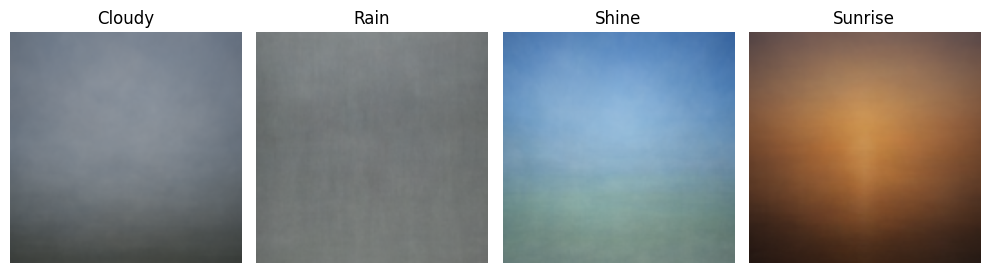

In [ ]:
def plot_average_images(images, labels, classes):
    plt.figure(figsize=(10, 10))
    for class_id, class_name in enumerate(classes):
        # Extract images belonging to the current class
        class_images = images[np.array(labels) == class_id]
        avg_image = np.mean(class_images, axis=0)  # Compute average image

        # Display the average image
        ax = plt.subplot(1, len(classes), class_id + 1)
        plt.imshow(avg_image)
        plt.title(class_name)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Define class names
class_names = ["Cloudy", "Rain", "Shine", "Sunrise"]

# Call the function
plot_average_images(images, labels, class_names)


### **Correlation Heatmap (Flattened Images)**

The correlation between pixel values across all images is visualized. The images are flattened into a 2D array, and a correlation matrix is computed. A heatmap is then plotted to show the relationships between pixel intensities Strong red color indicates high correlation and blue color indicate contrast patterns

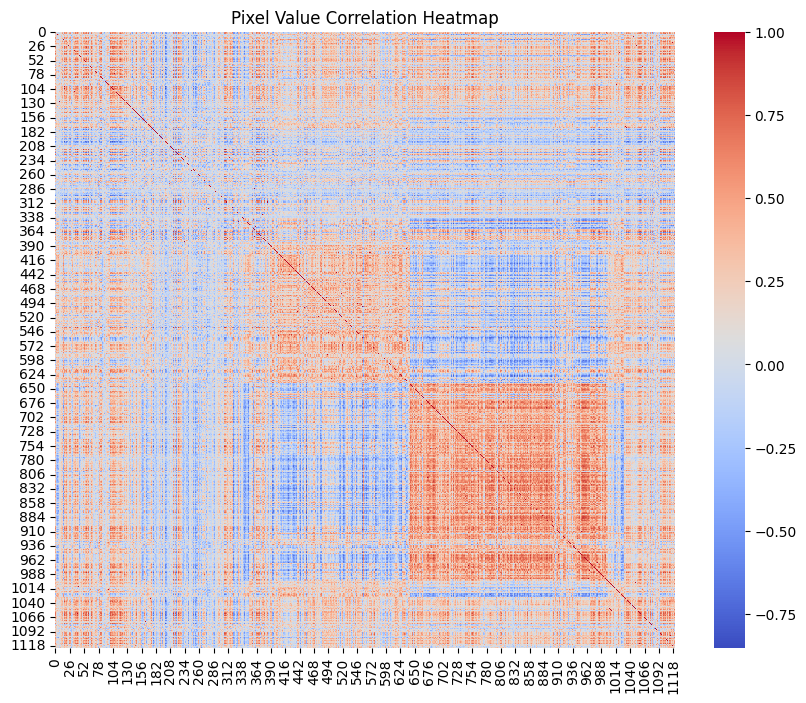

In [ ]:
def plot_correlation_heatmap(images):
    # Flatten images
    flat_images = images.reshape(images.shape[0], -1)
    # Calculate correlation matrix
    corr_matrix = np.corrcoef(flat_images)
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, cmap='coolwarm', cbar=True)
    plt.title("Pixel Value Correlation Heatmap")
    plt.show()

# Plot correlation heatmap
plot_correlation_heatmap(images)


### **Class Proportion Pie Chart**

The proportion of each class in the dataset is visualized as a pie chart.  The percentage of images in each category is calculated and displayed.

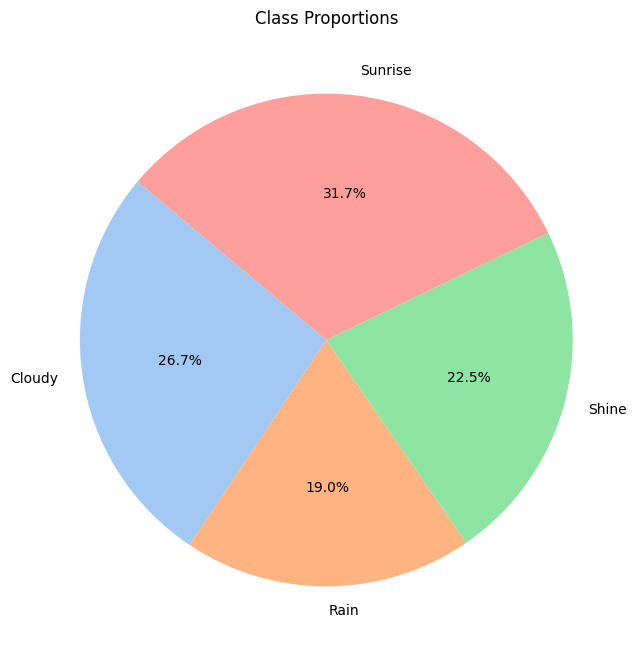

In [ ]:
def plot_class_proportions(labels):
    class_names = ["Cloudy", "Rain", "Shine", "Sunrise"]
    unique, counts = np.unique(labels, return_counts=True)

    plt.figure(figsize=(8, 8))
    plt.pie(counts, labels=class_names, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
    plt.title("Class Proportions")
    plt.show()

# Plot class proportions
plot_class_proportions(labels)


The pie chart above shows that the highest proportion is of Sunrise at 31.7% while that of rain is 19.0%.

### **Feature Variance Across Classes**

The variance in pixel values of each class is visualized in this plot. The variance of pixel intensities across all images within a class are calcukated

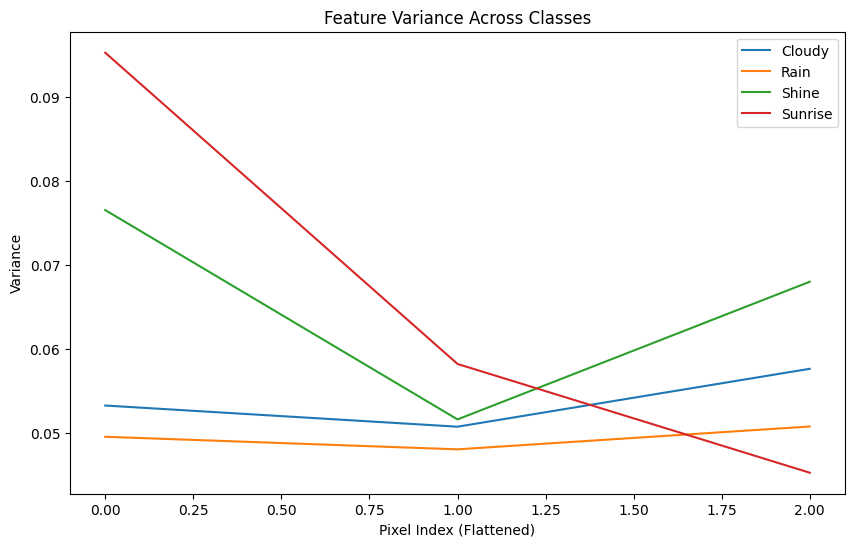

In [ ]:
def plot_class_feature_variance(images, labels, classes):
    plt.figure(figsize=(10, 6))
    for class_id, class_name in enumerate(classes):
        class_images = images[np.array(labels) == class_id]
        variance = np.var(class_images, axis=(0, 1, 2))  # Variance per class
        plt.plot(variance, label=class_name)

    plt.xlabel("Pixel Index (Flattened)")
    plt.ylabel("Variance")
    plt.title("Feature Variance Across Classes")
    plt.legend()
    plt.show()

# Plot feature variance
plot_class_feature_variance(images, labels, class_names)


### **Class-Wise Brightness Analysis**

The brightness levels of images in each class are analyzed by calculating the average brightness of all images within a class. This helps to compare the brightness levels across different classes.

<ipython-input-12-c04613876495>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=brightness, palette="viridis")


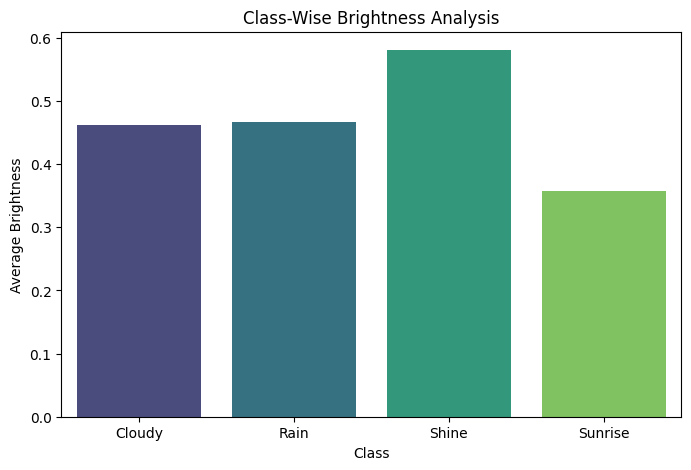

In [ ]:
def plot_class_brightness(images, labels, classes):
    brightness = []

    for class_id, class_name in enumerate(classes):
        class_images = images[np.array(labels) == class_id]
        avg_brightness = np.mean(class_images, axis=(1, 2, 3))  # Brightness per image
        brightness.append(np.mean(avg_brightness))  # Average brightness per class

    plt.figure(figsize=(8, 5))
    sns.barplot(x=classes, y=brightness, palette="viridis")
    plt.xlabel("Class")
    plt.ylabel("Average Brightness")
    plt.title("Class-Wise Brightness Analysis")
    plt.show()

# Plot class-wise brightness
plot_class_brightness(images, labels, class_names)



From the bar plot we can observe that the shine is the brightest among all classes.

### **Aspect Ratio Distribution Plot**

The histogram shows the distribution of aspect ratios, which is the width-to-height ratio of images. It provides insights into the most common aspect ratios in the dataset and highlights any irregularities or outliers. A density curve is also added to visualize the overall trend more clearly.

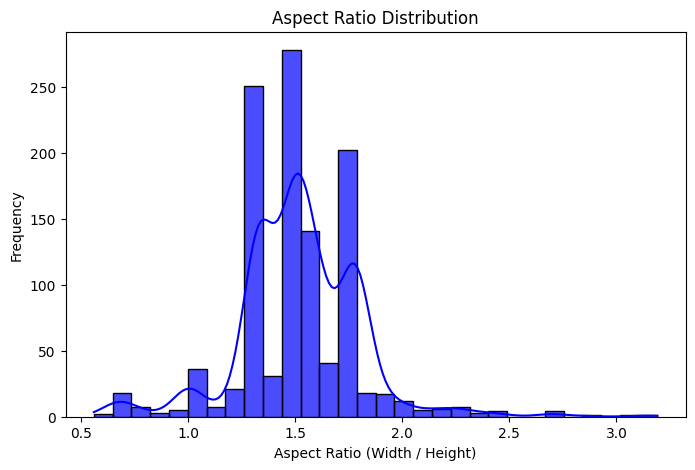

In [ ]:
def plot_aspect_ratio_distribution(folder_path):
    aspect_ratios = []

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if filename.endswith('.jpg'):
            try:
                with Image.open(file_path) as img:
                    aspect_ratios.append(img.width / img.height)
            except Exception as e:
                print(f"Error processing file {filename}: {e}")

    plt.figure(figsize=(8, 5))
    sns.histplot(aspect_ratios, bins=30, kde=True, color="blue", alpha=0.7)
    plt.xlabel("Aspect Ratio (Width / Height)")
    plt.ylabel("Frequency")
    plt.title("Aspect Ratio Distribution")
    plt.show()


plot_aspect_ratio_distribution(folder_path)


### **Color Channel Distribution Plot**


The histogram shows the distribution of pixel values for each color channel—red, green, and blue. It helps to analyze the intensity levels in each channel across the entire dataset. A density curve is overlaid for better visualization

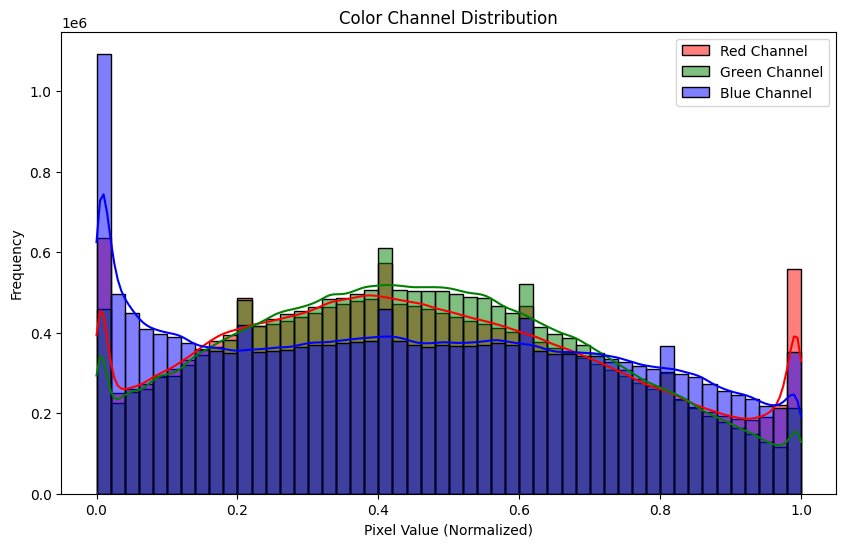

In [ ]:
def plot_color_channel_distribution(images):
    red_channel = images[:, :, :, 0].ravel()
    green_channel = images[:, :, :, 1].ravel()
    blue_channel = images[:, :, :, 2].ravel()

    plt.figure(figsize=(10, 6))
    sns.histplot(red_channel, bins=50, color="red", kde=True, label="Red Channel", alpha=0.5)
    sns.histplot(green_channel, bins=50, color="green", kde=True, label="Green Channel", alpha=0.5)
    sns.histplot(blue_channel, bins=50, color="blue", kde=True, label="Blue Channel", alpha=0.5)
    plt.xlabel("Pixel Value (Normalized)")
    plt.ylabel("Frequency")
    plt.title("Color Channel Distribution")
    plt.legend()
    plt.show()

# Plot color channel distribution
plot_color_channel_distribution(images)


### **Edge Detection Visualization for each class**


The plot displays edge maps for a few images from each class. Edges are detected by converting the images to grayscale and applying an edge detection algorithm. This helps to highlight the boundaries and structural details within each class, providing a better understanding of their distinct features

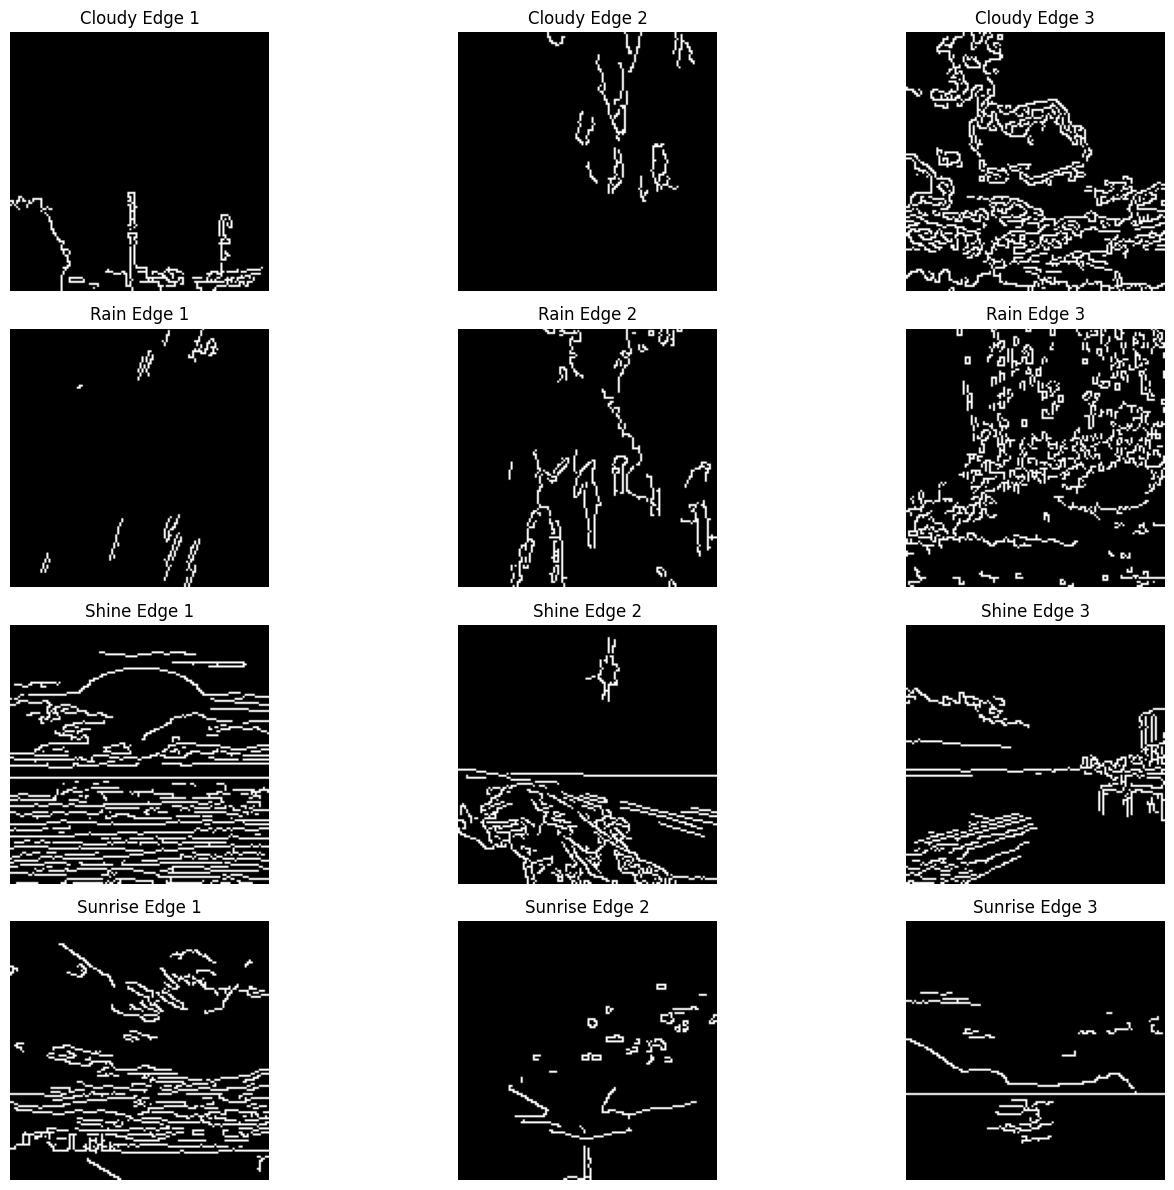

In [ ]:
import cv2
import matplotlib.pyplot as plt

def plot_class_edges(images, labels, classes, num_images_per_class=3):



    plt.figure(figsize=(15, len(classes) * 3))
    for class_id, class_name in enumerate(classes):
        # Extract images of the current class
        class_indices = [i for i, label in enumerate(labels) if label == class_id]
        selected_indices = class_indices[:num_images_per_class]  # Select first few images

        for i, idx in enumerate(selected_indices):
            # Convert image to grayscale and compute edges
            gray_image = cv2.cvtColor((images[idx] * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
            edges = cv2.Canny(gray_image, threshold1=100, threshold2=200)

            # Plot the edge map
            ax = plt.subplot(len(classes), num_images_per_class, class_id * num_images_per_class + i + 1)
            plt.imshow(edges, cmap="gray")
            plt.title(f"{class_name} Edge {i + 1}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

# Define class names
class_names = ["Cloudy", "Rain", "Shine", "Sunrise"]

# Visualize edges for each class
plot_class_edges(images, labels, class_names)



### **Image Sharpness Plot**

The histogram shows the distribution of sharpness levels across the dataset, calculated using the variance of the Laplacian of each image.

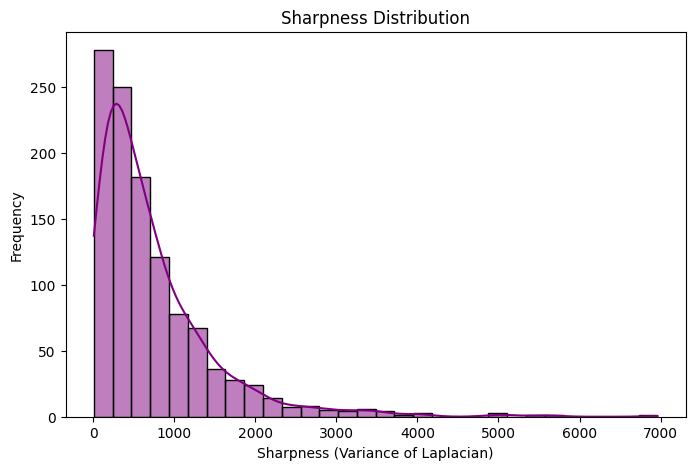

In [ ]:
def plot_sharpness_distribution(images):
    sharpness = []

    for img in images:
        gray_image = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY)
        sharpness.append(cv2.Laplacian(gray_image, cv2.CV_64F).var())

    plt.figure(figsize=(8, 5))
    sns.histplot(sharpness, bins=30, kde=True, color="purple")
    plt.xlabel("Sharpness (Variance of Laplacian)")
    plt.ylabel("Frequency")
    plt.title("Sharpness Distribution")
    plt.show()

# Plot sharpness distribution
plot_sharpness_distribution(images)


## **Identifying small images**

This function identifies images smaller than a specified minimum size (64x64 by default) in the dataset.

In [ ]:
def find_small_images(folder_path, min_size=(64, 64)):
    small_images = []

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if filename.endswith('.jpg'):  # Adjust extensions if needed
            try:
                with Image.open(file_path) as img:
                    if img.width < min_size[0] or img.height < min_size[1]:
                        small_images.append((filename, img.width, img.height))
            except Exception as e:
                print(f"Error processing file {filename}: {e}")

    print(f"Found {len(small_images)} small images:")
    for img in small_images:
        print(f" - {img[0]}: {img[1]}x{img[2]}")

    return small_images

# Identify and review small images
small_images = find_small_images(folder_path)


Found 0 small images:


## **Identifying large images and resizing the images**

The images larger than the maximum size of 1024*1024 are identified and listed. Then all the large images which are identified are resized to a target size of 256*256 pixels. The resized images are then normalized to a pixel value range of 0 and 1

In [ ]:
# Step 1: Identify Large Images
def find_large_images(folder_path, max_size=(1024, 1024)):
    large_images = []

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        if filename.endswith('.jpg'):
            try:
                with Image.open(file_path) as img:
                    if img.width > max_size[0] or img.height > max_size[1]:
                        large_images.append((filename, img.width, img.height))
            except Exception as e:
                print(f"Error processing file {filename}: {e}")

    print(f"Found {len(large_images)} large images:")
    for img in large_images:
        print(f" - {img[0]}: {img[1]}x{img[2]}")

    return large_images

# Identify large images
large_images = find_large_images(folder_path)

# Step 2: Resize Large Images
def resize_images(folder_path, target_size=(256, 256)):
    resized_images = []

    for filename, width, height in large_images:
        file_path = os.path.join(folder_path, filename)
        try:
            with Image.open(file_path).convert('RGB') as img:
                resized_img = img.resize(target_size)
                resized_images.append(np.array(resized_img) / 255.0)  # Normalize to [0, 1]
        except Exception as e:
            print(f"Error resizing file {filename}: {e}")

    print(f"Resized {len(resized_images)} large images to {target_size}.")
    return resized_images

# Resize identified large images
resized_large_images = resize_images(folder_path)



Found 70 large images:
 - cloudy55.jpg: 1600x971
 - cloudy60.jpg: 1077x1600
 - cloudy82.jpg: 1600x1067
 - rain100.jpg: 2059x1158
 - rain137.jpg: 3000x1997
 - rain144.jpg: 1600x1200
 - rain195.jpg: 1028x735
 - rain209.jpg: 2048x1360
 - rain37.jpg: 1600x1067
 - rain52.jpg: 2244x1458
 - rain63.jpg: 1191x670
 - rain69.jpg: 1600x900
 - rain72.jpg: 3000x2034
 - rain80.jpg: 2354x1325
 - rain85.jpg: 1920x1080
 - rain83.jpg: 1668x1500
 - rain88.jpg: 1920x1080
 - rain94.jpg: 1280x720
 - shine1.jpg: 1920x1080
 - shine113.jpg: 1920x1200
 - shine121.jpg: 1920x1080
 - shine140.jpg: 1200x680
 - shine55.jpg: 1680x1050
 - shine56.jpg: 2048x1536
 - shine62.jpg: 2000x1125
 - shine65.jpg: 1600x1200
 - shine67.jpg: 1920x1080
 - shine72.jpg: 1920x1080
 - shine77.jpg: 1080x1080
 - shine78.jpg: 1080x1080
 - shine9.jpg: 1600x1200
 - shine94.jpg: 2880x1800
 - sunrise10.jpg: 2304x1728
 - sunrise110.jpg: 1280x853
 - sunrise114.jpg: 1280x720
 - sunrise118.jpg: 1440x900
 - sunrise116.jpg: 2560x1600
 - sunrise123.jp

Few of the resized images are previewed to check if the resizing process was done correctly.

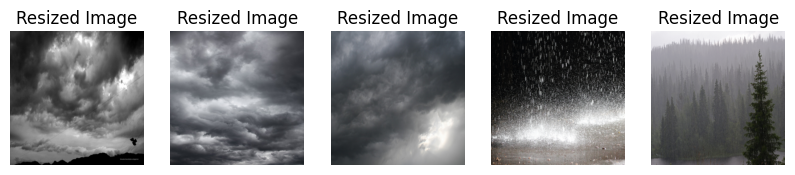

In [ ]:
# Step 3: Preview Resized Images
def preview_resized_large_images(images, num_images=5):
    plt.figure(figsize=(10, 10))
    for i in range(min(num_images, len(images))):
        ax = plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i])
        plt.title("Resized Image")
        plt.axis("off")

# Preview resized large images
preview_resized_large_images(resized_large_images)

## **Assigning weights to classes**

As we understood from the plots that the datset was imbalanced. To address that issue, class weights for each class based on frequency are calculated so that the imbalanced classes are given higher importance during model training.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

def calculate_class_weights(labels):
    classes = np.unique(labels)
    class_weights = compute_class_weight('balanced', classes=classes, y=labels)
    return dict(zip(classes, class_weights))

class_weights = calculate_class_weights(labels)
print("Class Weights:", class_weights)


Class Weights: {0: 0.935, 1: 1.3169014084507042, 2: 1.108695652173913, 3: 0.7879213483146067}


## **Displaying sample images of each class**

This function displays a few random images from each class.Three images per class are selected and displayed with clear labels for each class.

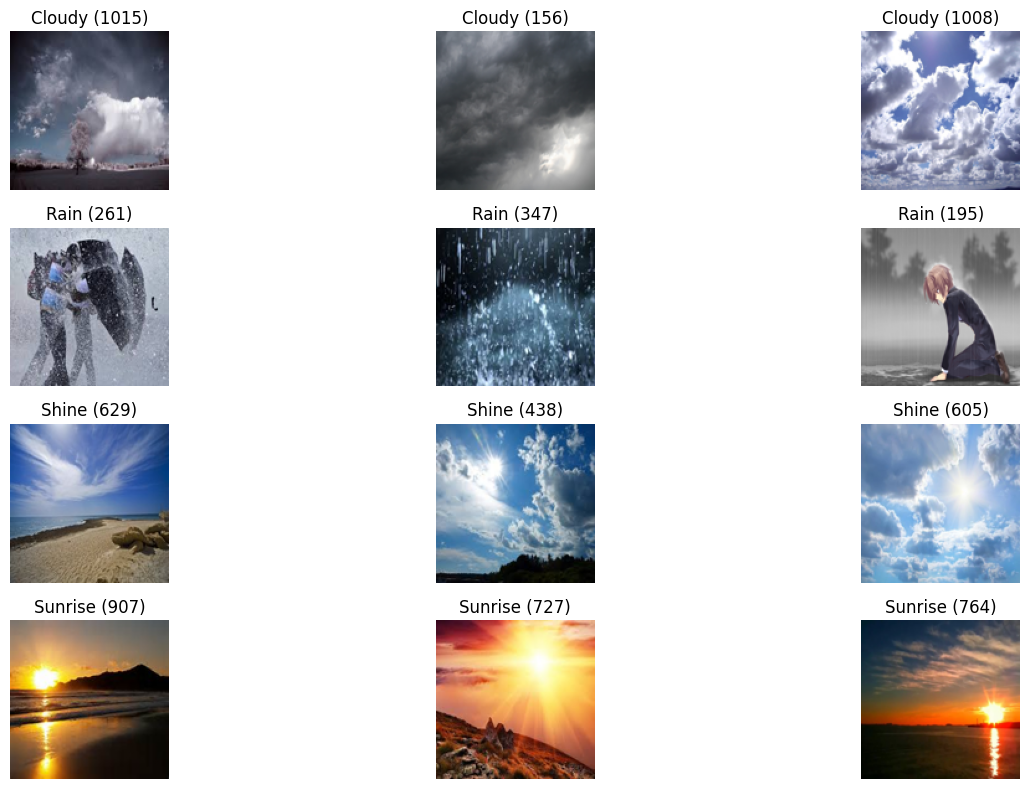

In [ ]:
import random
import matplotlib.pyplot as plt

def display_images_per_class(images, labels, num_images=3):
    classes = ["Cloudy", "Rain", "Shine", "Sunrise"]
    plt.figure(figsize=(15, 8))

    for class_id, class_name in enumerate(classes):
        # Get indices of images belonging to the current class
        indices = [i for i, label in enumerate(labels) if label == class_id]
        selected_indices = random.sample(indices, min(num_images, len(indices)))  # Randomly sample

        for i, idx in enumerate(selected_indices):
            plt.subplot(len(classes), num_images, class_id * num_images + i + 1)
            plt.imshow(images[idx])
            plt.title(f"{class_name} ({idx})")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

# Display 3 images per class
display_images_per_class(images, labels)


## **Splitting the dataset into training , validation and test.**

The function performs a stratified split of the dataset into training, validation, and test sets, ensuring that the class distribution is maintained across all splits.

In [ ]:
from sklearn.model_selection import train_test_split
def stratified_split(images, labels, test_size=0.2, val_size=0.2):
  # First split into train and temp (validation + test)
    X_train, X_temp, y_train, y_temp = train_test_split(
        images, labels, test_size=(test_size + val_size), stratify=labels, random_state=42
    )

    # Split temp into validation and test
    val_ratio = val_size / (test_size + val_size)  # Proportion of temp to allocate for validation
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=(1 - val_ratio), stratify=y_temp, random_state=42
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

# Perform the stratified split
X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(images, labels)

# Print dataset sizes
print(f"Training set: {len(X_train)} images")
print(f"Validation set: {len(X_val)} images")
print(f"Test set: {len(X_test)} images")

Training set: 673 images
Validation set: 224 images
Test set: 225 images


## **Summary Table**

The summary table includes the total number of images, the shape of the processed images, the calculated class weights, and the distribution of images across classes.

In [ ]:
import pandas as pd

def generate_preprocessing_summary(images, labels, class_weights, image_shape):
    """
    Generate a summary table of preprocessing steps and their results.

    Parameters:
    - images: numpy array of image data.
    - labels: numpy array of class labels.
    - class_weights: dictionary of class weights.
    - image_shape: tuple representing the shape of the processed images.

    Returns:
    - summary_df: pandas DataFrame containing the summary table.
    """
    # Class Distribution
    classes = ["Cloudy", "Rain", "Shine", "Sunrise"]
    unique, counts = np.unique(labels, return_counts=True)
    class_distribution = dict(zip(classes, counts))

    # Preprocessing Summary
    data = {
        "Metric": ["Total Images", "Image Shape", "Class Weights"] + [f"Images in {cls}" for cls in classes],
        "Result": [
            len(images),
            f"{image_shape[0]}x{image_shape[1]}x{image_shape[2]}",
            ", ".join([f"{cls}: {round(weight, 3)}" for cls, weight in class_weights.items()]),
        ] + [class_distribution[cls] for cls in classes]
    }

    summary_df = pd.DataFrame(data)
    return summary_df

# Generate the summary table
summary_df = generate_preprocessing_summary(images, labels, class_weights, images[0].shape)

# Display the summary table
print(summary_df.to_markdown(index=False))


| Metric            | Result                                 |
|:------------------|:---------------------------------------|
| Total Images      | 1122                                   |
| Image Shape       | 128x128x3                              |
| Class Weights     | 0: 0.935, 1: 1.317, 2: 1.109, 3: 0.788 |
| Images in Cloudy  | 300                                    |
| Images in Rain    | 213                                    |
| Images in Shine   | 253                                    |
| Images in Sunrise | 356                                    |


# **Saving the preprocessed data into drive**

The preprocessed images and labels are saved to google drive to be used for the next step.

In [ ]:
import numpy as np
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Save images and labels
save_path = '/content/drive/MyDrive/Preprocessed_MWD/'
os.makedirs(save_path, exist_ok=True)

np.save(os.path.join(save_path, 'images.npy'), images)
np.save(os.path.join(save_path, 'labels.npy'), labels)

print(f"Preprocessed data saved to {save_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Preprocessed data saved to /content/drive/MyDrive/Preprocessed_MWD/
